### 4.3 Ensemble: inverse-RMSE blend, and the flagship demo

[![content: AI-generated](../_static/badges/ai-generated.svg)](ai-acknowledgement) [![content: human-reviewed & edited](../_static/badges/human-reviewed-edited.svg)](ai-acknowledgement)

$$\hat y_{ens,h} = w_h\,\hat y_{SARIMA,h} + (1-w_h)\,\hat y_{EN,h}$$

$$w_h \propto \frac{1}{\mathrm{RMSE}_{SARIMA,h}}$$

Whichever family won at *that specific horizon* in the walk-forward comparison gets more say: the weight can and does change from horizon 1 to horizon 8. This is also the
project's reportable forecast, so it's the one worth actually watching get built: the cell
below truncates to the project's pinned forecast origin, draws 1,000 Monte-Carlo paths from
the fitted SARIMA + Elastic Net components, combines them horizon-by-horizon, and animates
a sample of them fanning out into the **raw, uncalibrated** simulated interval (a nominal 80%/50%). Press play. This is *not* the same interval `forecast.csv`/the live API actually serve. See the width comparison after the animation for exactly how much narrower it is.

*Source: `src/models/ensemble.py`*

In [1]:
import sys, warnings
from pathlib import Path

PROJECT_ROOT = Path.cwd()
for _ in range(4):
    if (PROJECT_ROOT / "reports").is_dir() and (PROJECT_ROOT / "data").is_dir():
        break
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

INK, PAPER, ACCENT, ACCENT_SOFT, HIGHLIGHT, GRID = (
    "#16211c", "#f7f8f5", "#1f6f66", "#bfe3dd", "#a8691f", "#d9ddd6",
)
BLUE, PLUM, MUTED, ALERT = "#5b6f8f", "#8a4f8a", "#9aa79f", "#c0392b"
plt.rcParams.update({
    "figure.facecolor": PAPER, "axes.facecolor": PAPER, "axes.edgecolor": GRID,
    "axes.labelcolor": INK, "text.color": INK, "xtick.color": INK, "ytick.color": INK,
    "font.size": 11, "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False,
})

import matplotlib.dates as mdates

def year_axis(ax, step=5):
    ax.xaxis.set_major_locator(mdates.YearLocator(step))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

CURATED = PROJECT_ROOT / "data" / "curated" / "quarterly_macro_features.csv"
TABLEAU = PROJECT_ROOT / "reports" / "tableau"

#### Explained, step by step

- This is a weighted average of the two accuracy-family forecasts at a given horizon $h$. If $w_h=0.7$, the ensemble forecast is 70% SARIMA's number and 30% Elastic Net's number, for that horizon specifically.
- The weight is set by each model's own track record at that horizon: $w_h$ is proportional to $1/\mathrm{RMSE}_{SARIMA,h}$. The worse SARIMA's historical RMSE at horizon $h$, the smaller its share (small RMSE $\to$ large $1/\mathrm{RMSE}$ $\to$ more weight; large RMSE $\to$ small $1/\mathrm{RMSE}$ $\to$ less weight). In practice this is normalized so the two inverse-RMSEs sum to 1: $w_h = \dfrac{1/\mathrm{RMSE}_{SARIMA,h}}{1/\mathrm{RMSE}_{SARIMA,h} + 1/\mathrm{RMSE}_{EN,h}}$. Because the weight is computed *per horizon*, SARIMA can dominate at horizon 1 while Elastic Net dominates at horizon 6, if that's what the walk-forward accuracy says.
- Intuition: the same logic as weighting two independent instrument readings by how noisy each one is. Trust the more reliable source more, with the weighting adapting automatically rather than being hand-picked.

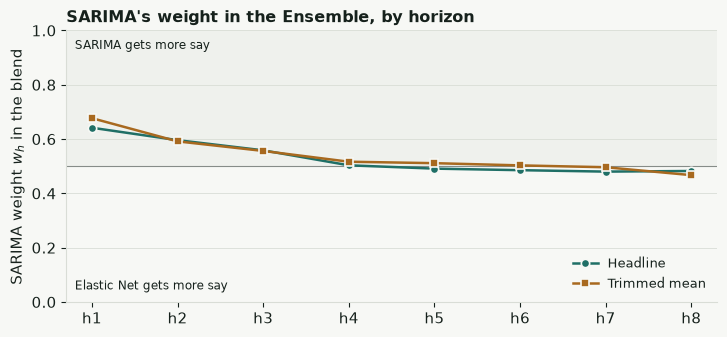

In [2]:
from src.models import ensemble

horizons = list(range(1, 9))
series = {}
for label, column, color, marker in [
    ("Headline", "cpi_yoy", ACCENT, "o"),
    ("Trimmed mean", "trimmed_mean_cpi_yoy", HIGHLIGHT, "s"),
]:
    w = ensemble.horizon_rmse_weights(horizons=tuple(horizons), path=ensemble.dynamic_weights_source_path(column))
    series[label] = ([w[h][0] for h in horizons], color, marker)

fig, ax = plt.subplots(figsize=(7.4, 3.5))
ax.axhline(0.5, color=INK, linewidth=0.8, alpha=0.5)
ax.fill_between([0.7, 8.3], 0.5, 1.0, color=GRID, alpha=0.25, linewidth=0)
for label, (vals, color, marker) in series.items():
    ax.plot(horizons, vals, color=color, marker=marker, markersize=6, markeredgecolor=PAPER, markeredgewidth=1.2,
            linewidth=1.8, label=label)
ax.text(0.8, 0.965, "SARIMA gets more say", fontsize=8.5, va="top")
ax.text(0.8, 0.035, "Elastic Net gets more say", fontsize=8.5, va="bottom")
ax.set_xlim(0.7, 8.3)
ax.legend(frameon=False, fontsize=9, loc="lower right")
ax.set_ylim(0, 1)
ax.set_xticks(horizons, [f"h{h}" for h in horizons])
ax.set_ylabel("SARIMA weight $w_h$ in the blend")
ax.set_title("SARIMA's weight in the Ensemble, by horizon", loc="left", fontsize=11.5, fontweight="bold")
ax.grid(axis="x", visible=False)
fig.tight_layout()
plt.show()

**Static snapshot of the animation above.** A Jupyter Book page is static HTML, so instead of embedding a ~15MB animation, the chart below reveals the same pinned draws at four checkpoints (1, 10, 40, and all 120 sampled paths), for both targets. It's built from the checked-in draw samples (`reports/simulation_paths_sample_ensemble*.csv`) and bands (`reports/simulation_fan_ensemble*.csv`), so it can be regenerated. Each column reveals more of the same 120 sampled paths, while the shaded bands always come from all 1,000 draws.

All of this starts from the project's shared forecast origin, 2025Q4: the curated data runs a little past it, but every report is cut there so they all use the same information and the later quarters stay available as real outcomes to score against.

In [3]:
from src.models import ensemble, svar
from src.models.elastic_net import ELASTIC_NET_FEATURE_COLUMNS, TARGET_COLUMN, load_elastic_net_feature_frame
from src.models.evaluation import load_target_series
from src.models.interval_coverage import DEFAULT_SEED
from src.models.simulation_fan import DEFAULT_N_SIMS

ORIGIN = svar.FORECAST_ORIGIN_PIN  # 2025Q4 -- the same pin every other report in this project shares

series = load_target_series(CURATED, target_column=TARGET_COLUMN)
features = load_elastic_net_feature_frame(CURATED, feature_columns=ELASTIC_NET_FEATURE_COLUMNS)
frame = pd.concat([series.rename(TARGET_COLUMN), features], axis=1).dropna().sort_index()

# The curated data runs past the pin; cut both series there so the fan starts from the same information as every other report
series = series.loc[:ORIGIN]
frame = frame.loc[:ORIGIN]
assert series.index[-1] == frame.index[-1] == ORIGIN

paths = ensemble.simulate_ensemble_paths(
    frame, steps=8, n_sims=DEFAULT_N_SIMS, seed=DEFAULT_SEED,
    target_column=TARGET_COLUMN, sarima_series=series,
)
forecast_origin = str(frame.index[-1])
quarters = [str(frame.index[-1] + h) for h in range(1, 9)]
p10, p25, med, p75, p90 = np.percentile(paths, [10, 25, 50, 75, 90], axis=0)

# Reproducibility guard: same pin, same seed and same method as the checked-in report, so the simulated fan should match it.
# It can only drift if ABS has since revised a historical print, in which case the reports need refreshing before this page.
checked_in = pd.read_csv(PROJECT_ROOT / "reports/simulation_fan_ensemble.csv").sort_values("horizon")
assert checked_in["forecast_origin"].iloc[0] == forecast_origin, (checked_in["forecast_origin"].iloc[0], forecast_origin)
for name, simulated in (("p10", p10), ("median", med), ("p90", p90)):
    assert np.allclose(simulated, checked_in[name].to_numpy(), atol=0.005), (
        f"simulated {name} no longer matches reports/simulation_fan_ensemble.csv")


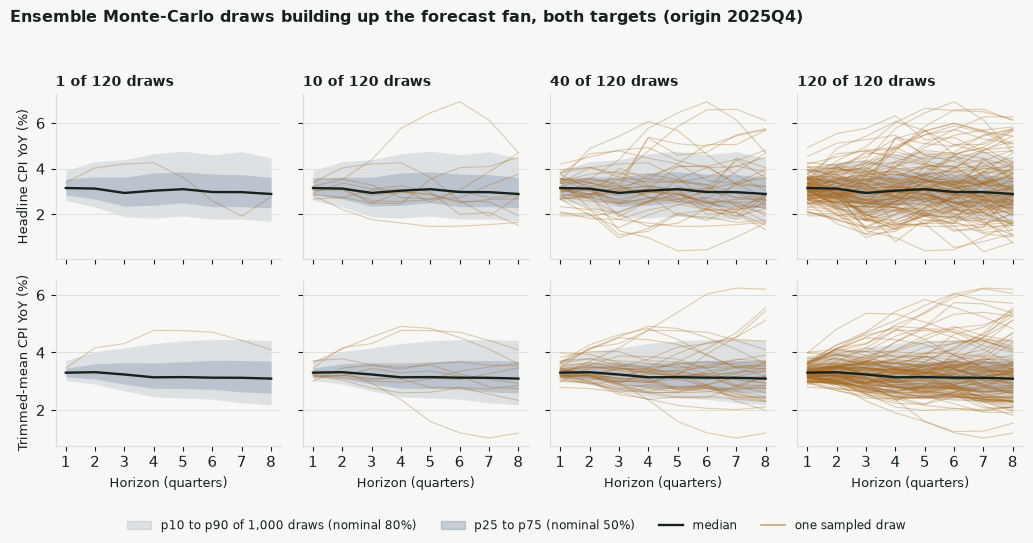

In [4]:
fan_h = pd.read_csv(PROJECT_ROOT / "reports/simulation_fan_ensemble.csv").sort_values("horizon")
fan_t = pd.read_csv(PROJECT_ROOT / "reports/simulation_fan_ensemble_trimmed_mean.csv").sort_values("horizon")
paths_h = pd.read_csv(PROJECT_ROOT / "reports/simulation_paths_sample_ensemble.csv")
paths_t = pd.read_csv(PROJECT_ROOT / "reports/simulation_paths_sample_ensemble_trimmed_mean.csv")
targets = [("Headline CPI YoY (%)", fan_h, paths_h), ("Trimmed-mean CPI YoY (%)", fan_t, paths_t)]
checkpoints = [1, 10, 40, 120]
n_draws = paths_h["draw_id"].nunique()
assert n_draws == paths_t["draw_id"].nunique() == max(checkpoints)
assert fan_h["forecast_origin"].iloc[0] == fan_t["forecast_origin"].iloc[0] == paths_h["forecast_origin"].iloc[0]

# The text below quotes the raw (uncalibrated) coverage on the held-out 2020-23 origins. Re-check it on every re-run.
for path, expected in (("reports/model_interval_calibration_validation.csv", {"ensemble": 33.6, "sarima": 57.3, "elastic_net": 44.5}),
                       ("reports/model_interval_calibration_validation_trimmed_mean.csv", {"ensemble": 32.8, "sarima": 57.8, "elastic_net": 49.2})):
    raw = pd.read_csv(PROJECT_ROOT / path)
    raw = raw[raw["horizon"].astype(str) == "overall"].set_index("model")["raw_empirical_coverage"]
    assert {k: round(raw[k] * 100, 1) for k in expected} == expected, f"raw coverage changed in {path}: update the text"

fig, axes = plt.subplots(2, len(checkpoints), figsize=(10.4, 5.4), sharex=True, sharey="row")
for r, (label, fan, paths) in enumerate(targets):
    wide = paths.pivot(index="draw_id", columns="horizon", values="value").sort_index()
    for c, n in enumerate(checkpoints):
        ax = axes[r, c]
        ax.fill_between(fan["horizon"], fan["p10"], fan["p90"], color=BLUE, alpha=0.16, linewidth=0)
        ax.fill_between(fan["horizon"], fan["p25"], fan["p75"], color=BLUE, alpha=0.26, linewidth=0)
        for draw in wide.index[:n]:
            ax.plot(wide.columns, wide.loc[draw].to_numpy(), color=HIGHLIGHT, alpha=0.32, linewidth=0.8)
        ax.plot(fan["horizon"], fan["median"], color=INK, linewidth=1.7)
        ax.set_xticks(range(1, 9))
        ax.grid(axis="x", visible=False)
        if r == 0:
            ax.set_title(f"{n} of {n_draws} draws", loc="left", fontsize=10, fontweight="bold")
        if c == 0:
            ax.set_ylabel(label, fontsize=9.5)
        if r == 1:
            ax.set_xlabel("Horizon (quarters)", fontsize=9)
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
fig.legend(handles=[Patch(color=BLUE, alpha=0.16, label="p10 to p90 of 1,000 draws (nominal 80%)"),
                    Patch(color=BLUE, alpha=0.30, label="p25 to p75 (nominal 50%)"),
                    Line2D([], [], color=INK, linewidth=1.7, label="median"),
                    Line2D([], [], color=HIGHLIGHT, alpha=0.6, linewidth=1.2, label="one sampled draw")],
           frameon=False, fontsize=8.6, loc="lower center", ncol=4)
fig.suptitle("Ensemble Monte-Carlo draws building up the forecast fan, both targets (origin 2025Q4)", x=0.01, ha="left",
             fontsize=11.5, fontweight="bold")
fig.tight_layout(rect=(0, 0.06, 1, 0.95))
plt.show()

```{tip}
To actually drag the slider or press **▶ Play** and watch the paths reveal continuously, open **4.3 Ensemble** in the [live demo](https://cpi-forecast-demo.streamlit.app/), or run `streamlit run app/streamlit_app.py` from the project root.
```

**What the p10 to p90 band is.** It's made of empirical percentiles: for each horizon, the 10th and 90th percentile of the simulated draws, not a formula like the mean plus or minus 1.28 standard deviations. The draws come from two recipes. SARIMA's are Gaussian draws from the fitted model (with no parameter uncertainty), and Elastic Net's are a residual bootstrap from out-of-sample cross-validation residuals. The Ensemble blends the two with the horizon weights and recentres them on the point forecast.

The 80% is therefore a *nominal* target, not a measured hit rate. On the held-out 2020 to 2023 origins, the raw Ensemble band caught only about a third of the outcomes (33.6% for headline, 32.8% for trimmed mean), against about 57% for SARIMA and 45% to 49% for Elastic Net. That's why the interval the project actually serves is wider, as the next charts show.

**How much wider is the interval the project actually serves?** About 3.6 times wider than the raw band for headline CPI, and about 3.0 times wider for trimmed-mean CPI.

raw vs. calibrated interval width -- h1: 1.32 vs 4.77 (3.61x)  |  h8: 2.77 vs 10.02 (3.61x)


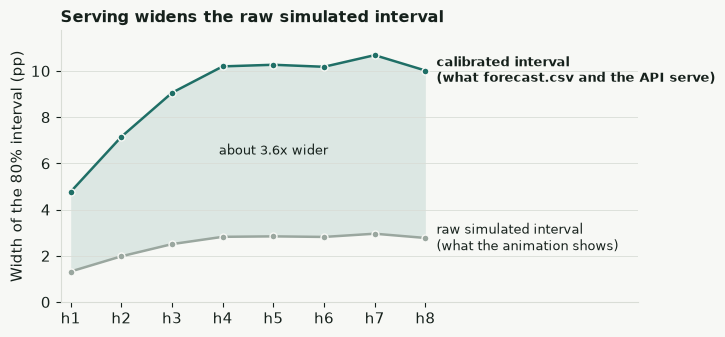

In [5]:
raw = pd.read_csv(PROJECT_ROOT / "reports/simulation_fan_ensemble.csv").sort_values("horizon")
served = pd.read_csv(TABLEAU / "forecast.csv")
served = served[(served["model_family"] == "ensemble") & (served["target"] == "Headline")].sort_values("horizon")

horizons = raw["horizon"].to_numpy()
raw_width = (raw["p90"] - raw["p10"]).to_numpy()
served_width = (served["interval_upper"] - served["interval_lower"]).to_numpy()
scale = served_width / raw_width
print(f"raw vs. calibrated interval width -- h1: {raw_width[0]:.2f} vs {served_width[0]:.2f} ({scale[0]:.2f}x)  |  "
      f"h8: {raw_width[-1]:.2f} vs {served_width[-1]:.2f} ({scale[-1]:.2f}x)")

fig, ax = plt.subplots(figsize=(7.4, 3.5))
ax.fill_between(horizons, raw_width, served_width, color=ACCENT, alpha=0.12, linewidth=0)
ax.plot(horizons, raw_width, color=MUTED, marker="o", markersize=5, markeredgecolor=PAPER, linewidth=1.8)
ax.plot(horizons, served_width, color=ACCENT, marker="o", markersize=5, markeredgecolor=PAPER, linewidth=1.8)
ax.annotate("raw simulated interval\n(what the animation shows)", (horizons[-1], raw_width[-1]),
            xytext=(8, 0), textcoords="offset points", va="center", fontsize=9)
ax.annotate("calibrated interval\n(what forecast.csv and the API serve)", (horizons[-1], served_width[-1]),
            xytext=(8, 0), textcoords="offset points", va="center", fontsize=9, fontweight="bold")
mid = 4
ax.text(horizons[mid], (raw_width[mid] + served_width[mid]) / 2, f"about {scale.mean():.1f}x wider", ha="center",
        va="center", fontsize=9, color=INK)
ax.set_xlim(0.8, 12.2)
ax.set_ylim(0, served_width.max() * 1.1)
ax.set_xticks(horizons, [f"h{h}" for h in horizons])
ax.set_ylabel("Width of the 80% interval (pp)")
ax.set_title("Serving widens the raw simulated interval", loc="left", fontsize=11.5, fontweight="bold")
ax.grid(axis="x", visible=False)
fig.tight_layout()
plt.show()

trimmed mean, raw vs. calibrated interval width -- h1: 0.70 vs 2.10 (3.02x)  |  h8: 2.24 vs 6.76 (3.02x)


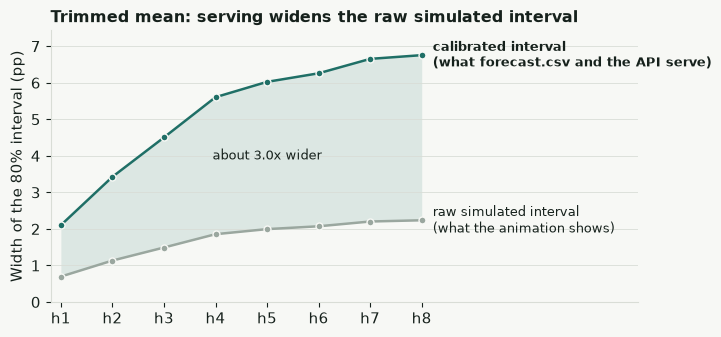

In [6]:
raw = pd.read_csv(PROJECT_ROOT / "reports/simulation_fan_ensemble_trimmed_mean.csv").sort_values("horizon")
served = pd.read_csv(TABLEAU / "forecast.csv")
served = served[(served["model_family"] == "ensemble") & (served["target"] == "Trimmed mean")].sort_values("horizon")

horizons = raw["horizon"].to_numpy()
raw_width = (raw["p90"] - raw["p10"]).to_numpy()
served_width = (served["interval_upper"] - served["interval_lower"]).to_numpy()
scale = served_width / raw_width
print(f"trimmed mean, raw vs. calibrated interval width -- h1: {raw_width[0]:.2f} vs {served_width[0]:.2f} ({scale[0]:.2f}x)  |  "
      f"h8: {raw_width[-1]:.2f} vs {served_width[-1]:.2f} ({scale[-1]:.2f}x)")

fig, ax = plt.subplots(figsize=(7.4, 3.5))
ax.fill_between(horizons, raw_width, served_width, color=ACCENT, alpha=0.12, linewidth=0)
ax.plot(horizons, raw_width, color=MUTED, marker="o", markersize=5, markeredgecolor=PAPER, linewidth=1.8)
ax.plot(horizons, served_width, color=ACCENT, marker="o", markersize=5, markeredgecolor=PAPER, linewidth=1.8)
ax.annotate("raw simulated interval\n(what the animation shows)", (horizons[-1], raw_width[-1]),
            xytext=(8, 0), textcoords="offset points", va="center", fontsize=9)
ax.annotate("calibrated interval\n(what forecast.csv and the API serve)", (horizons[-1], served_width[-1]),
            xytext=(8, 0), textcoords="offset points", va="center", fontsize=9, fontweight="bold")
mid = 4
ax.text(horizons[mid], (raw_width[mid] + served_width[mid]) / 2, f"about {scale.mean():.1f}x wider", ha="center",
        va="center", fontsize=9, color=INK)
ax.set_xlim(0.8, 12.2)
ax.set_ylim(0, served_width.max() * 1.1)
ax.set_xticks(horizons, [f"h{h}" for h in horizons])
ax.set_ylabel("Width of the 80% interval (pp)")
ax.set_title("Trimmed mean: serving widens the raw simulated interval", loc="left", fontsize=11.5, fontweight="bold")
ax.grid(axis="x", visible=False)
fig.tight_layout()
plt.show()